In [1]:
import pandas as pd
import os
import logging
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Configure logging
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")

In [3]:
#Define file paths
sentiment_dir = os.path.join("..", "data", "sentiment")
output_file = os.path.join(sentiment_dir, "sentiment_analysis_report.txt")

In [4]:
#Load the sentiment dataset
logging.info(f"Loading sentiment analysis results from: {os.path.join(sentiment_dir, 'sentiment_analysis.csv')}")
df = pd.read_csv(os.path.join(sentiment_dir, "sentiment_analysis.csv"))

2025-03-23 10:30:16,087 - INFO - Loading sentiment analysis results from: ../data/sentiment/sentiment_analysis.csv


In [5]:
#Ensure required columns exist
required_columns = {"final_sentiment", "Source", "vader_score", "disagreement_flag", "text"}
missing_columns = required_columns - set(df.columns)
if missing_columns:
    raise ValueError(f"Missing required columns in sentiment dataset: {', '.join(missing_columns)}")

#'final_sentiment' is derived based on sentiment analysis models (e.g., VADER & TextBlob).
#It represents the final decision on sentiment classification (Positive, Neutral, Negative).

/var/folders/wc/lj0_3jjn1zv0_y7s7thm5jqw0000gn/T/ipykernel_70648/232706986.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="final_sentiment", data=df, palette="coolwarm", order=["Positive", "Neutral", "Negative"])


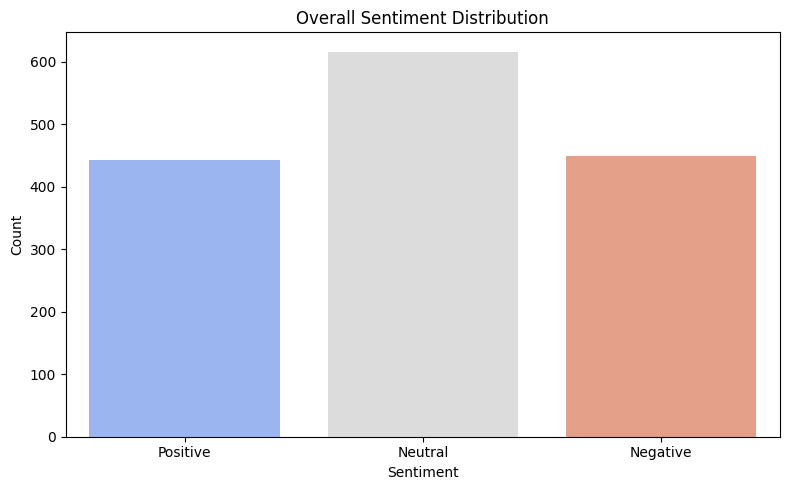

2025-03-23 10:30:16,291 - INFO - 📊 Sentiment distribution plot saved.


In [6]:
#Plot 1: Sentiment Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x="final_sentiment", data=df, palette="coolwarm", order=["Positive", "Neutral", "Negative"])
plt.title("Overall Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(sentiment_dir, "sentiment_distribution.png"))
plt.show()
plt.close()
report = []
report.append("📊 Overall Sentiment Distribution plot saved to: sentiment_distribution.png")
logging.info("📊 Sentiment distribution plot saved.")

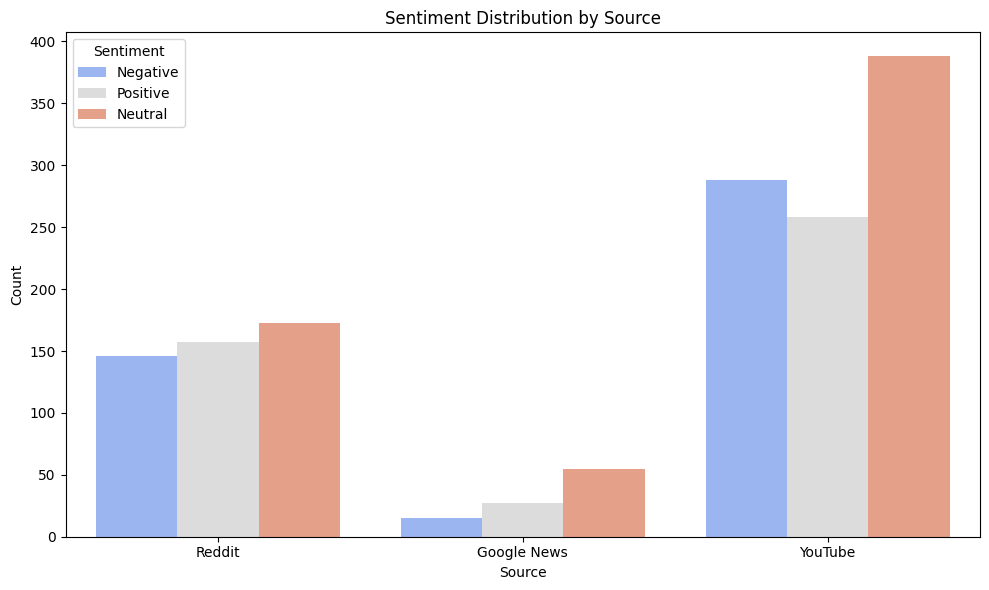

2025-03-23 10:30:16,584 - INFO - 📊 Sentiment by source plot saved.


In [7]:
#Plot 2: Sentiment by Source
plt.figure(figsize=(10, 6))
sns.countplot(x="Source", hue="final_sentiment", data=df, palette="coolwarm", order=df["Source"].unique())
plt.title("Sentiment Distribution by Source")
plt.xlabel("Source")
plt.ylabel("Count")
plt.legend(title="Sentiment")
plt.tight_layout()
plt.savefig(os.path.join(sentiment_dir, "sentiment_by_source.png"))
plt.show()
plt.close()
report = []
report.append("📊 Sentiment by source plot saved to: sentiment_by_source.png")
logging.info("📊 Sentiment by source plot saved.")

In [8]:
#Find Most Extreme Positive & Negative Comments
positive_threshold = 0.8
negative_threshold = -0.8
top_n = 5

most_positive = df[df["vader_score"] > positive_threshold].nlargest(top_n, "vader_score")[["text", "Source", "vader_score"]]
most_negative = df[df["vader_score"] < negative_threshold].nsmallest(top_n, "vader_score")[["text", "Source", "vader_score"]]

report.append(f"\n🔎 Top {top_n} Most Positive Comments (VADER score > {positive_threshold}):")
logging.info(f"\n🔎 Top {top_n} Most Positive Comments (VADER score > {positive_threshold}):")
for index, row in most_positive.iterrows():
    report.append(f"  Source: {row['Source']}")
    report.append(f"  VADER Score: {row['vader_score']:.4f}")
    report.append(f"  Text: {row['text']}")
    report.append("-" * 40)
    logging.info(f"  Source: {row['Source']}")
    logging.info(f"  VADER Score: {row['vader_score']:.4f}")
    logging.info(f"  Text: {row['text']}")
    logging.info("-" * 40)

report.append(f"\n❄️ Top {top_n} Most Negative Comments (VADER score < {negative_threshold}):")
logging.info(f"\n❄️ Top {top_n} Most Negative Comments (VADER score < {negative_threshold}):")
for index, row in most_negative.iterrows():
    report.append(f"  Source: {row['Source']}")
    report.append(f"  VADER Score: {row['vader_score']:.4f}")
    report.append(f"  Text: {row['text']}")
    report.append("-" * 40)
    logging.info(f"  Source: {row['Source']}")
    logging.info(f"  VADER Score: {row['vader_score']:.4f}")
    logging.info(f"  Text: {row['text']}")
    logging.info("-" * 40)

2025-03-23 10:30:16,593 - INFO - 
🔎 Top 5 Most Positive Comments (VADER score > 0.8):
2025-03-23 10:30:16,595 - INFO -   Source: YouTube
2025-03-23 10:30:16,595 - INFO -   VADER Score: 0.9994
2025-03-23 10:30:16,596 - INFO -   Text: case abolishing westminster system embracing canadian republic westminster system governance rooted tradition british colonial rule fundamentally flawed applied modern independent nation like canada westminster model concentrate much power hand executive leaving citizen mercy unchecked ruling class monarchy though ceremonial undermines democratic sovereignty vesting much power distant foreign figurehead governor general though theoretically neutral unelected representative monarchy hold sway significant political decision system weaken foundational principle selfgovernance personal liberty accountability essential truly free nation instead maintaining outdated system canada shift toward republican form government grounded principle representative democracy 

In [9]:
#Check VADER & TextBlob Disagreement
#'disagreement_flag' is set to "Yes" when VADER and TextBlob sentiment classifications do not match, 
#indicating uncertainty or model inconsistency.
disagreement_count = df["disagreement_flag"].eq("Yes").sum()
total_count = len(df)
disagreement_percent = (disagreement_count / total_count) * 100 if total_count > 0 else 0

disagreement_info = f"\n⚖️ VADER & TextBlob Disagree on {disagreement_percent:.2f}% of comments."
report.append(disagreement_info)
logging.info(disagreement_info)

report.append("\n✅ Sentiment analysis results review complete!")
logging.info("✅ Sentiment analysis results review complete!")

2025-03-23 10:30:16,620 - INFO - 
⚖️ VADER & TextBlob Disagree on 9.75% of comments.
2025-03-23 10:30:16,622 - INFO - ✅ Sentiment analysis results review complete!


In [10]:
#Write the combined report to a file
with open(output_file, "w") as f:
    for line in report:
        f.write(line + "\n")
logging.info(f"📝 Combined results saved to: {output_file}")

2025-03-23 10:30:16,628 - INFO - 📝 Combined results saved to: ../data/sentiment/sentiment_analysis_report.txt
